# Customer Segmentation with Clustering

**Objective:** Use unsupervised machine learning to discover distinct customer groups from mall data, then build supervised and advanced models on top of those insights.

**Pipeline:**
- Exploratory Data Analysis (EDA)
- Preprocessing with sklearn `Pipeline` + `ColumnTransformer`
- Segmentation Models: K-Means, Hierarchical - AgglomerativeClustering,  DBSCAN
- Hyperparameter Optimisation with Optuna
- Supervised Cluster Predictor (XGBoost)
- Silhouette Score, PCA Visualisation & Evaluation Summary
---

## Step 1: Setup — Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

sns.set_style('whitegrid')

## Step 2: Loading the Dataset

In [2]:
# load from local path
# df = pd.read_csv("Mall_Customers.csv")

# download from kagglehub
# !pip install kagglehub -q
import kagglehub, os
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))

print(f"Dataset loaded — shape: {df.shape}")
df.head()

Dataset loaded — shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 3: Exploratory Data Analysis (EDA)

We explore feature distributions, pairwise relationships, and the 3-D structure of the data before fitting any model.

In [3]:
print("Dataset Info:")
df.info()

# Drop identifier column — not a feature
df.drop(columns=['CustomerID'], inplace=True)

df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print("\nDescriptive Statistics:")
print(df.describe())

print(f"\nMissing values: {df.isna().sum().sum()}")
print("\nGender distribution:")
print(df['Gender'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Descriptive Statistics:
              Age  Annual_Income  Spending_Score
count  200.000000     200.000000      200.000000
mean    38.850000      60.560000       50.200000
std     13.969007      26.264721       25.823522
min     18.000000      15.000000        1.000000
25%     28.750000      41.500000       34.750000
50%     36.000000      61.500000       50.000000
75%     49.000000      78.000000       73.000000
max     70.000000     137.000000       99.000000

Missing values: 0

Gend

### 3.1 Univariate Distributions

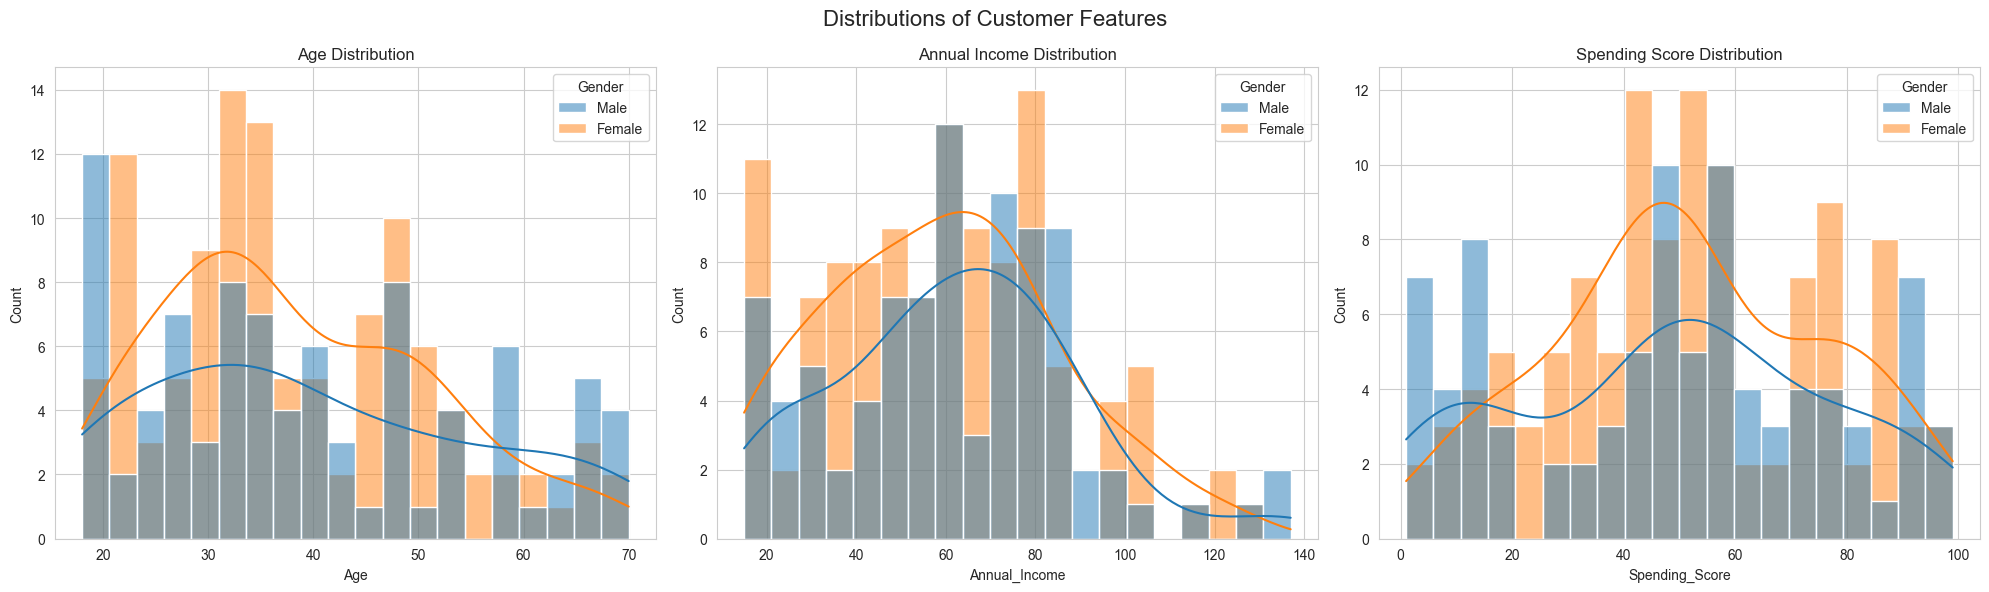

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distributions of Customer Features', fontsize=16)

sns.histplot(ax=axes[0], data=df, x='Age',
             kde=True, bins=20, hue='Gender').set_title('Age Distribution')
sns.histplot(ax=axes[1], data=df, x='Annual_Income',
             kde=True, bins=20, hue='Gender').set_title('Annual Income Distribution')
sns.histplot(ax=axes[2], data=df, x='Spending_Score',
             kde=True, bins=20, hue='Gender').set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

### 3.2 Bivariate Relationships

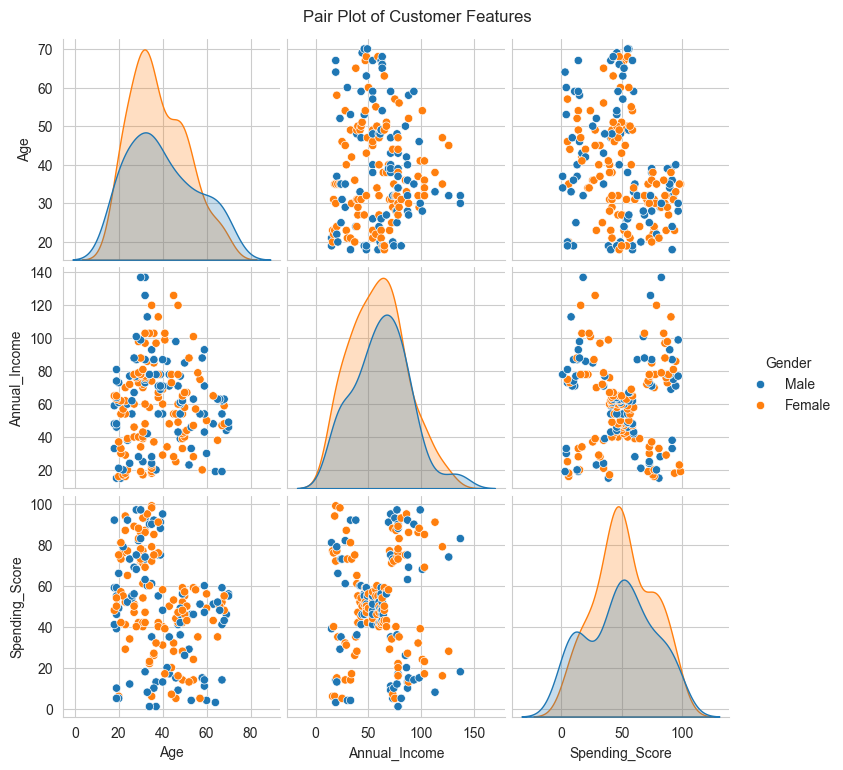

In [5]:
sns.pairplot(df,
             vars=['Age', 'Annual_Income', 'Spending_Score'],
             hue='Gender', diag_kind='kde')
plt.suptitle('Pair Plot of Customer Features', y=1.02)
plt.show()

**Observations:**
- **Annual Income vs Spending Score:** Most visually distinct clustering signal: 5 natural groups emerge.
- **Age vs Spending Score:** High-spending customers concentrate in younger brackets (< 40).
- **Gender:** Largely overlapping:(not a strong seperating feature)

### 3.3 Interactive 3-D View

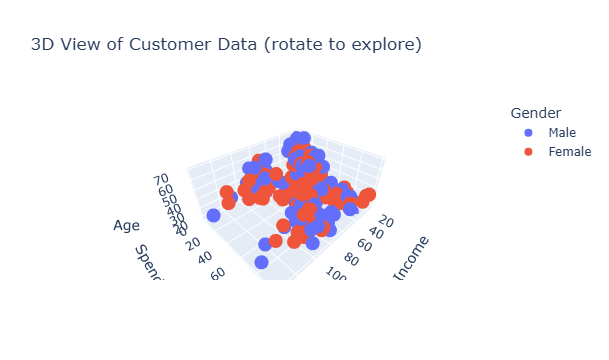

In [6]:
fig = px.scatter_3d(df,
                    x='Annual_Income',
                    y='Spending_Score',
                    z='Age',
                    color='Gender',
                    title='3D View of Customer Data (rotate to explore)')
fig.show()

## Step 4: Preprocessing Pipeline with ColumnTransformer

We build a **reusable sklearn Pipeline** that handles:
1. **Numerical features** → `StandardScaler`
2. **Categorical features** → `OneHotEncoder(drop='first')`

This ensures no data-leakage and clean, reproducible transformations.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Gender          200 non-null    str  
 1   Age             200 non-null    int64
 2   Annual_Income   200 non-null    int64
 3   Spending_Score  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


In [9]:
# Columns
numerical_features   = ['Annual_Income', 'Spending_Score', 'Age']
categorical_features = ['Gender']

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
])

# Fit-transform
X_all = df[numerical_features + categorical_features]
X_processed = preprocessor.fit_transform(X_all)

# Feature names
feature_names_out = (
    numerical_features +
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(categorical_features)
    .tolist()
)

print(f"Processed shape: {X_processed.shape}")
print("Features:", feature_names_out)

Processed shape: (200, 4)
Features: ['Annual_Income', 'Spending_Score', 'Age', 'Gender_Male']


In [10]:
# Scale helper
def scale_features(df, cols):
    scaler = StandardScaler()
    return scaler.fit_transform(df[cols]), scaler

## Step 5: Reusable Helper Functions

We evaluate k with two complementary metrics:
- **WCSS (Inertia):** Measures compactness — lower is better but always decreases.
- **Silhouette Score:** Measures separation quality — higher is better (range −1 to 1).

In [12]:
def evaluate_k(X_scaled, title, k_range=range(2, 11)):
    wcss, silhouette, db_scores = [], [], []

    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)

        wcss.append(km.inertia_)
        silhouette.append(silhouette_score(X_scaled, labels))
        db_scores.append(davies_bouldin_score(X_scaled, labels))

    # Best k based on silhouette
    best_k = list(k_range)[np.argmax(silhouette)]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Optimal k — {title}', fontsize=14)

    # Elbow
    axes[0].plot(k_range, wcss, marker='o', linestyle='--')
    axes[0].set_title('Elbow (WCSS)')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('WCSS')

    # Silhouette
    axes[1].plot(k_range, silhouette, marker='o')
    axes[1].axvline(best_k, linestyle=':', label=f'Best k={best_k}')
    axes[1].set_title('Silhouette')
    axes[1].legend()

    # Davies-Bouldin
    axes[2].plot(k_range, db_scores, marker='o')
    axes[2].set_title('Davies-Bouldin (lower=better)')

    plt.tight_layout()
    plt.show()

    return best_k

### 5.1: Fit + Evaluate Model

In [13]:
def fit_kmeans_model(X_scaled, k):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db  = davies_bouldin_score(X_scaled, labels)

    print(f"k={k} | Silhouette: {sil:.4f} | DB: {db:.4f}")

    return km, labels

### 5.2: Plot Clusters

In [14]:
def plot_clusters(df, x_col, y_col, labels, centroids=None, scaler=None, title="Clusters"):
    plt.figure(figsize=(12, 8))

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=labels,
        palette='viridis',
        s=120,
        alpha=0.85,
        edgecolor='black'
    )

    # Plot centroids (if provided)
    if centroids is not None and scaler is not None:
        centroids_orig = scaler.inverse_transform(centroids)
        plt.scatter(
            centroids_orig[:, 0],
            centroids_orig[:, 1],
            c='red',
            s=200,
            marker='X',
            label='Centroids'
        )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 6: Segmentation Model 1: Income vs Spending Score

**Features:** `Annual_Income`, `Spending_Score`  
**Pipeline:** `StandardScaler` (sklearn) → `KMeans`

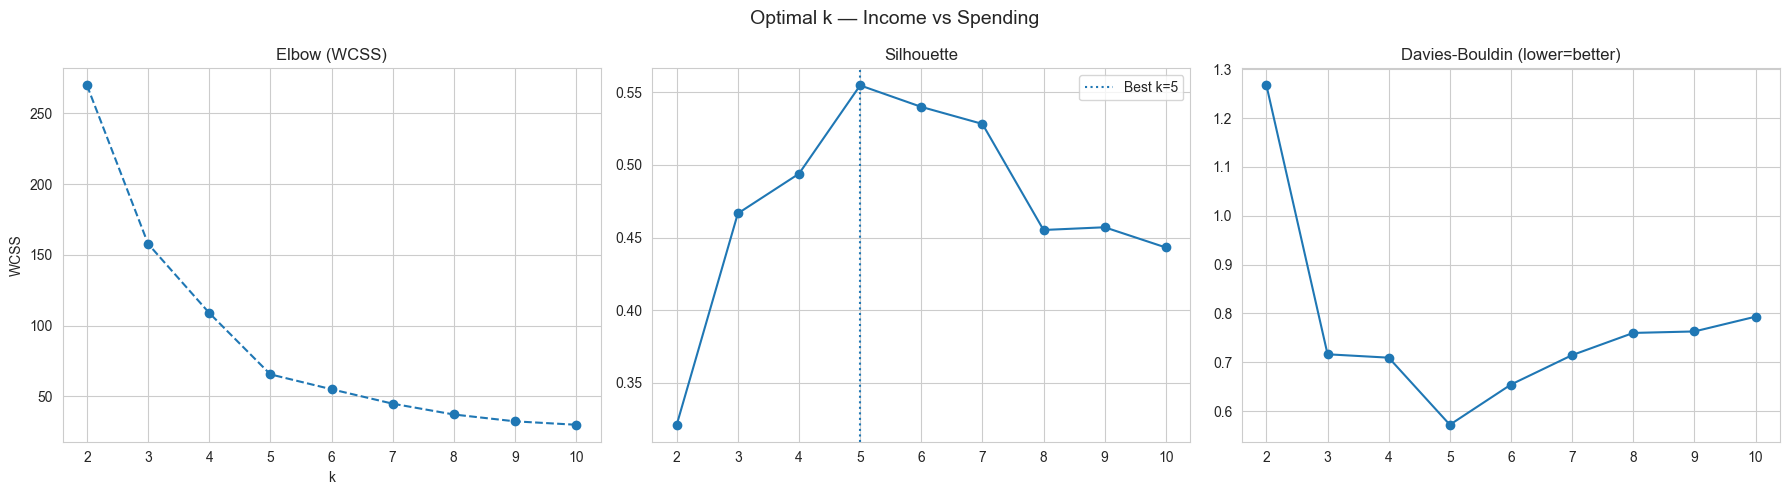

k=5 | Silhouette: 0.5547 | DB: 0.5722


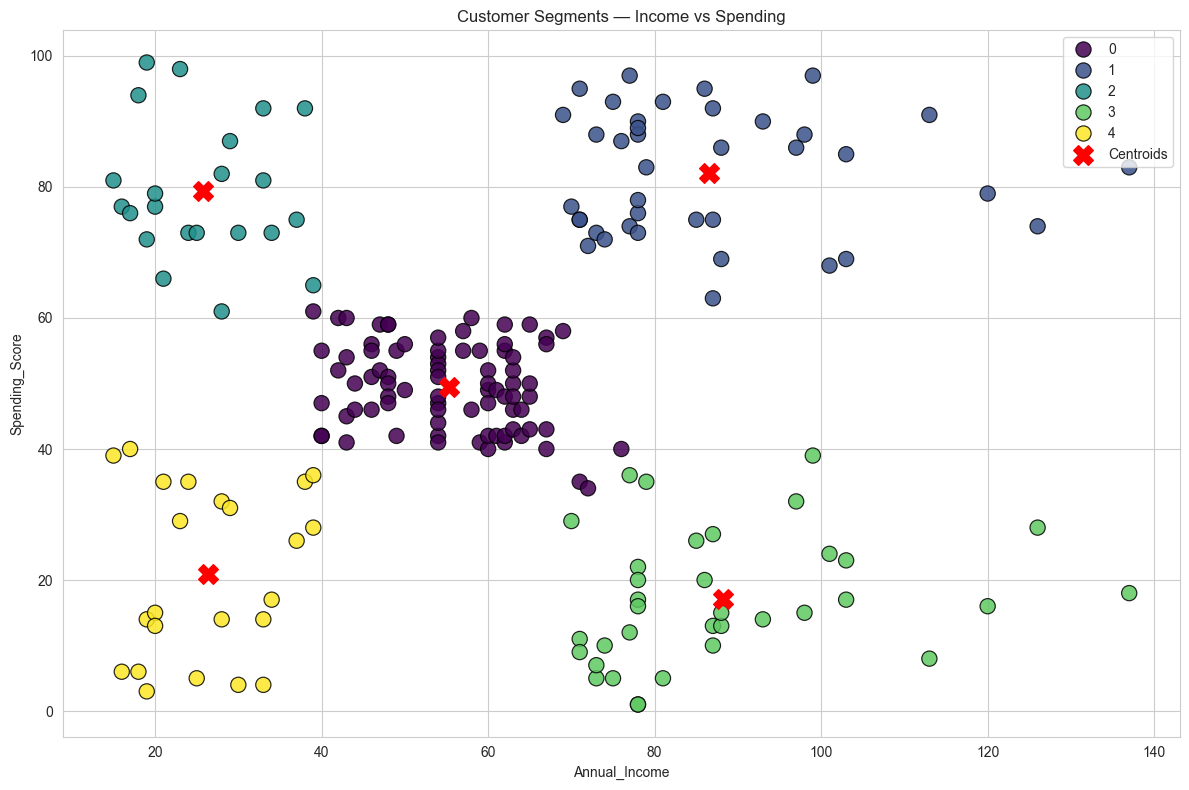

In [16]:
# Scale
X1_scaled, scaler1 = scale_features(df, ['Annual_Income', 'Spending_Score'])

# Evaluate k
best_k1 = evaluate_k(X1_scaled, 'Income vs Spending')

# Choose k (business override allowed)
k1 = 5  # or best_k1

# Fit model
kmeans1, labels1 = fit_kmeans_model(X1_scaled, k1)

df['Income_Cluster'] = labels1

# Plot
plot_clusters(
    df,
    'Annual_Income',
    'Spending_Score',
    labels1,
    centroids=kmeans1.cluster_centers_,
    scaler=scaler1,
    title='Customer Segments — Income vs Spending'
)

In [19]:
cluster_profiles1 = (df.groupby('Income_Cluster')[['Age', 'Annual_Income', 'Spending_Score']]
                       .mean().round(2))
cluster_profiles1['Size'] = df['Income_Cluster'].value_counts().sort_index()
cluster_profiles1.index.name = 'Cluster'
print("Income-Based Cluster Profiles:")
cluster_profiles1

Income-Based Cluster Profiles:


,Age,Annual_Income,Spending_Score,Size
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


## Step 7: Segmentation Model 2: Age × Spending Score

**Features:** `Age`, `Spending_Score`  
**Pipeline:** `StandardScaler` → `KMeans`

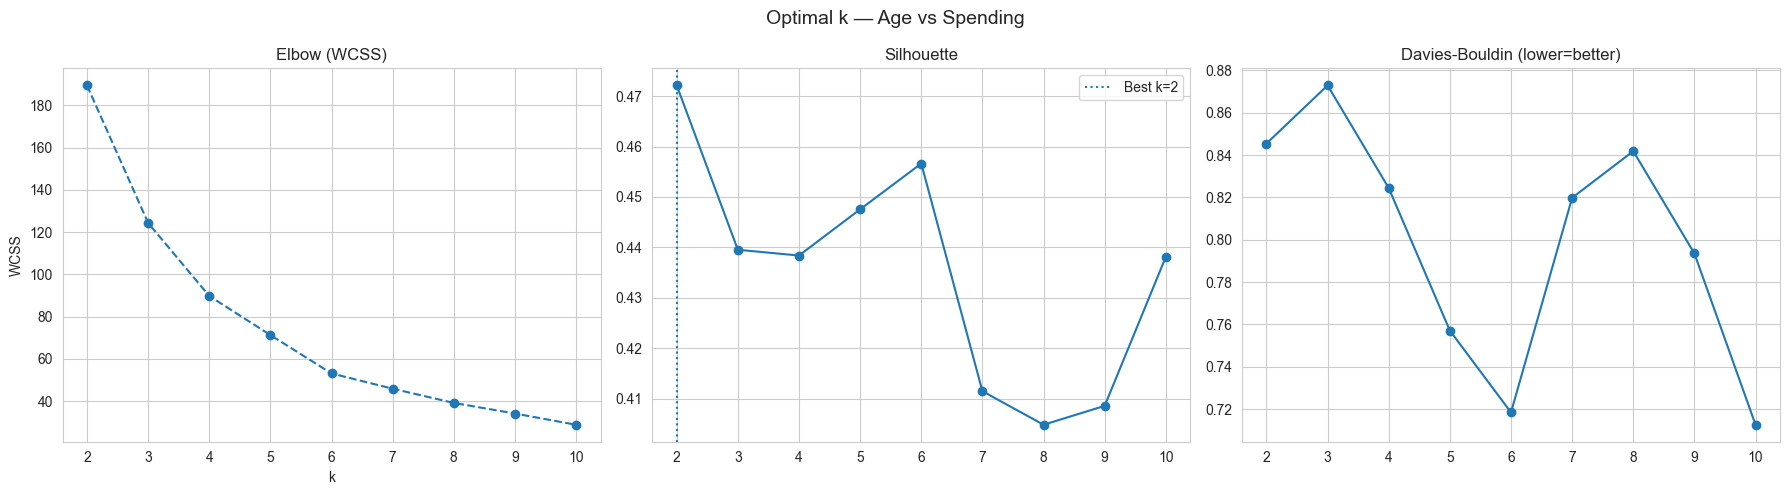


Recommended k: 2
k=2 | Silhouette: 0.4721 | DB: 0.8454


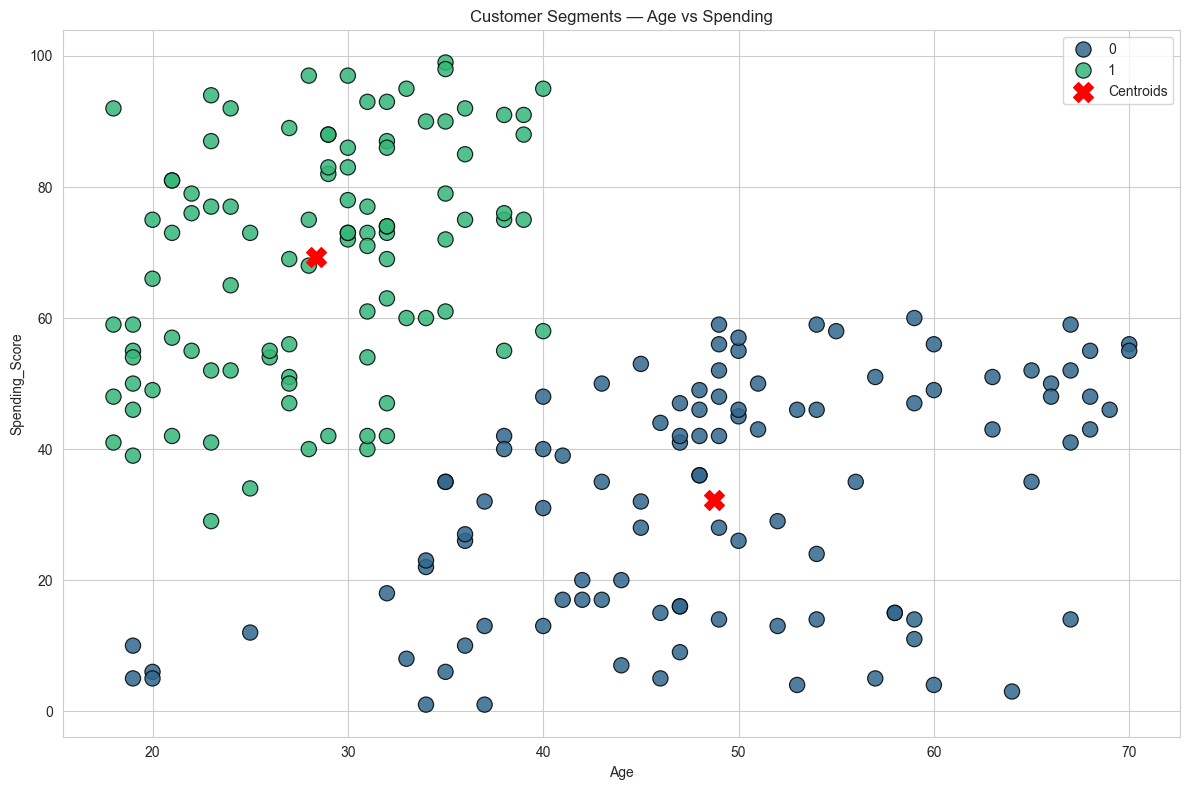

In [21]:
# Scale
X2_scaled, scaler2 = scale_features(df, ['Age', 'Spending_Score'])

# Evaluate k
best_k2 = evaluate_k(X2_scaled, 'Age vs Spending')

# Choose k
print(f"\nRecommended k: {best_k2}")
k2 = 2  # or best_k2

# Fit model
kmeans2, labels2 = fit_kmeans_model(X2_scaled, k2)

df['Age_Cluster'] = labels2

# Plot
plot_clusters(
    df,
    'Age',
    'Spending_Score',
    labels2,
    centroids=kmeans2.cluster_centers_,
    scaler=scaler2,
    title='Customer Segments — Age vs Spending'
)

In [22]:
cluster_profiles2 = (df.groupby('Age_Cluster')[['Annual_Income', 'Spending_Score']]
                       .mean().round(2))
cluster_profiles2['Size'] = df['Age_Cluster'].value_counts().sort_index()
cluster_profiles2.index.name = 'Cluster'
print("Age-Spending Cluster Profiles")
cluster_profiles2

Age-Spending Cluster Profiles


,Annual_Income,Spending_Score,Size
Cluster,,,
0,60.50,32.18,103
1,60.63,69.33,97


**Insights:**
- **Young High-Spenders (< 40, high score):** Trend-driven; respond to social-media campaigns.
- **Young Low-Spenders (< 40, low score):** Browsing but not converting — potential for targeted incentives.
- **Older Moderate-Spenders (> 40):** Consistent, reliable buyers; value reliability and service quality.
- **Older Low-Spenders:** Smaller group; infrequent visits — retention or win-back campaigns.

## Step 8: Segmentation Model 3: Gender vs Spending Score

**Encoding:** `OneHotEncoder(drop='first')`  
**Pipeline:** `ColumnTransformer` (OHE + StandardScaler) → `KMeans`

Shape: (200, 2)


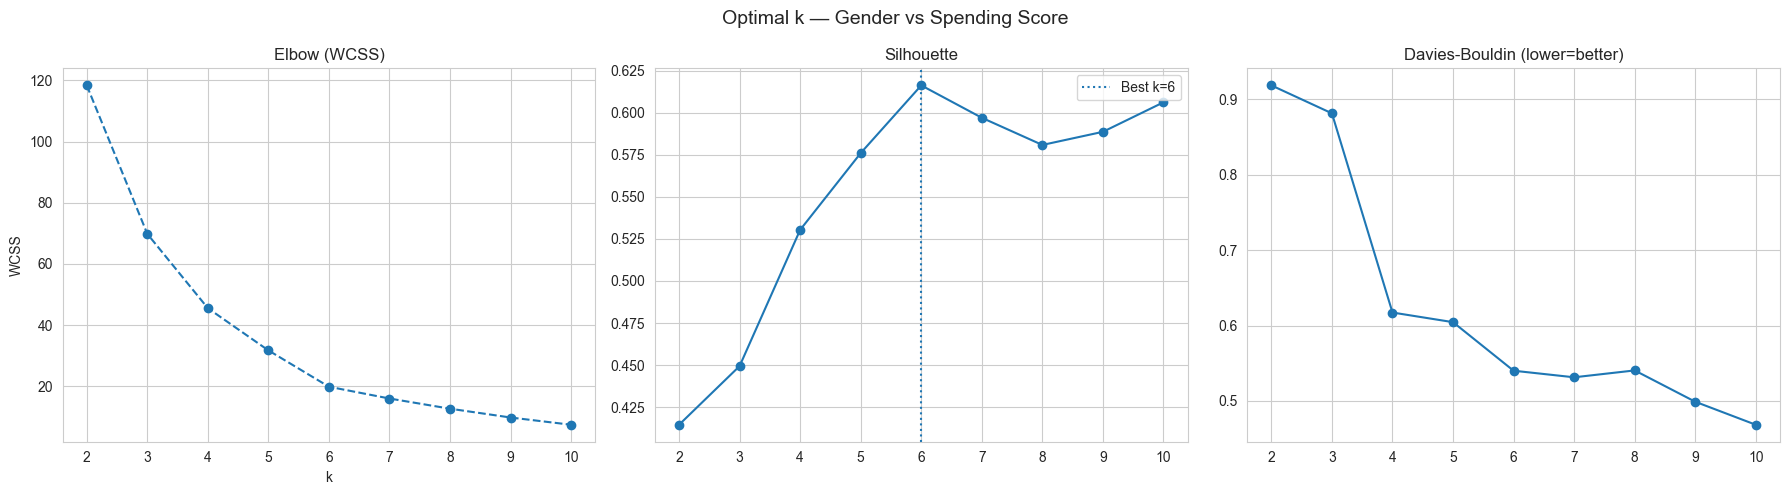

Recommended k: 6


In [31]:
# Select features
features_3 = ['Gender', 'Spending_Score']
X3 = df[features_3]

# Preprocessor
gender_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['Spending_Score']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ['Gender'])
])

# Transform
X3_scaled = gender_preprocessor.fit_transform(X3)
print("Shape:", X3_scaled.shape)

best_k3 = evaluate_k(X3_scaled, 'Gender vs Spending Score')
print(f"Recommended k: {best_k3}")

In [33]:
# train
k3 = best_k3
print("Model 3: Gender × Spending:")
kmeans3, labels3 = fit_kmeans_model(X3_scaled, k3)

df['Gender_Spending_Cluster'] = labels3

Model 3: Gender × Spending:
k=6 | Silhouette: 0.6163 | DB: 0.5400


Model 3 — Gender × Spending:


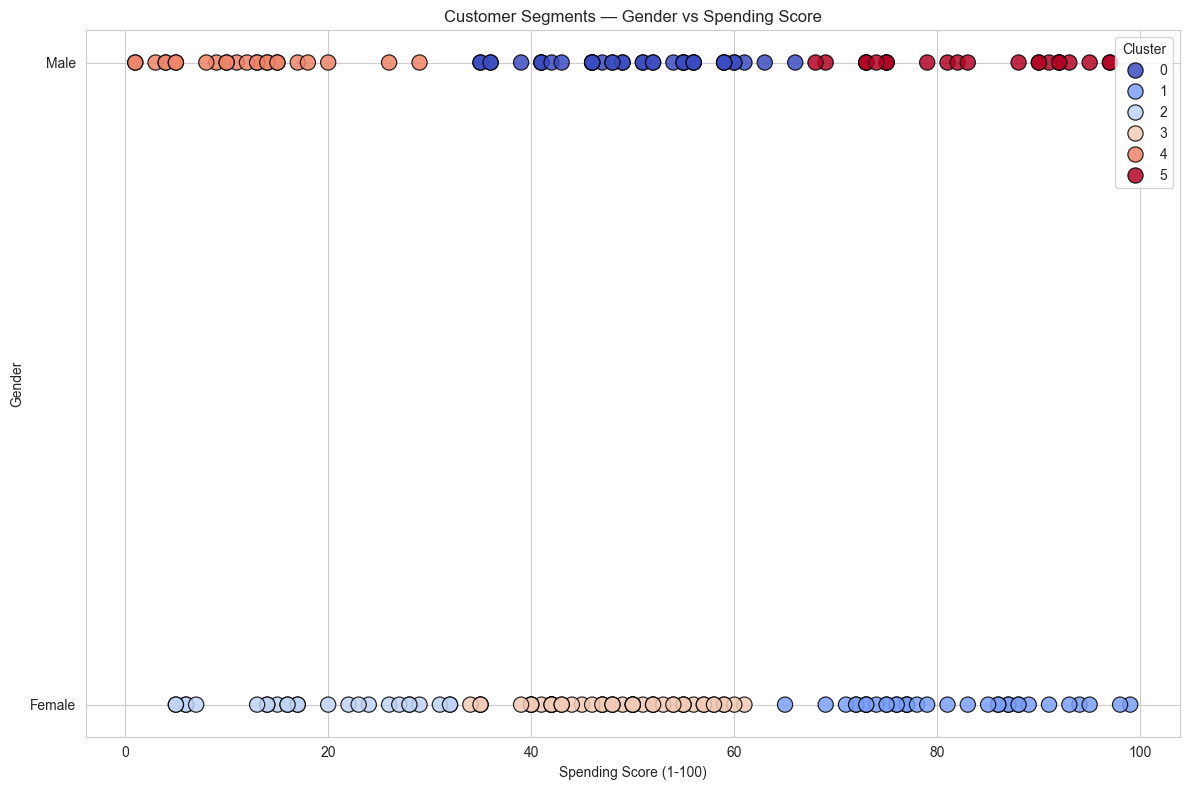

In [35]:
print("Model 3 — Gender × Spending:")
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Spending_Score',
    y='Gender',
    hue='Gender_Spending_Cluster',
    palette='coolwarm',
    s=120,
    alpha=0.85,
    edgecolor='black'
)

plt.title('Customer Segments — Gender vs Spending Score')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Gender')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [36]:
cluster_profiles3 = (
    df.groupby('Gender_Spending_Cluster')[['Spending_Score']]
      .mean()
      .round(2)
)

cluster_profiles3['Size'] = (
    df['Gender_Spending_Cluster']
    .value_counts()
    .sort_index()
)

cluster_profiles3.index.name = 'Cluster'

print("Gender × Spending Cluster Profiles")
print(cluster_profiles3)

Gender × Spending Cluster Profiles
         Spending_Score  Size
Cluster                      
0                 49.88    40
1                 81.24    34
2                 18.92    25
3                 47.85    53
4                 11.54    24
5                 83.21    24


**Observations:**
- High and low spending sub-groups exist within both genders.
- Female customers show generally higher spending scores on average.
- Male high-spenders display wider spread — greater individual variation.

## Step 9: Segmentation Model 4 — Spending Propensity

**Engineered Feature:** `Spending_Propensity = Spending Score / (Annual Income + ε)`  
This captures *relative* spend — a high propensity means the customer spends a large share of their income.

**`SpendingPropensityTransformer`** for this feature engineering step.

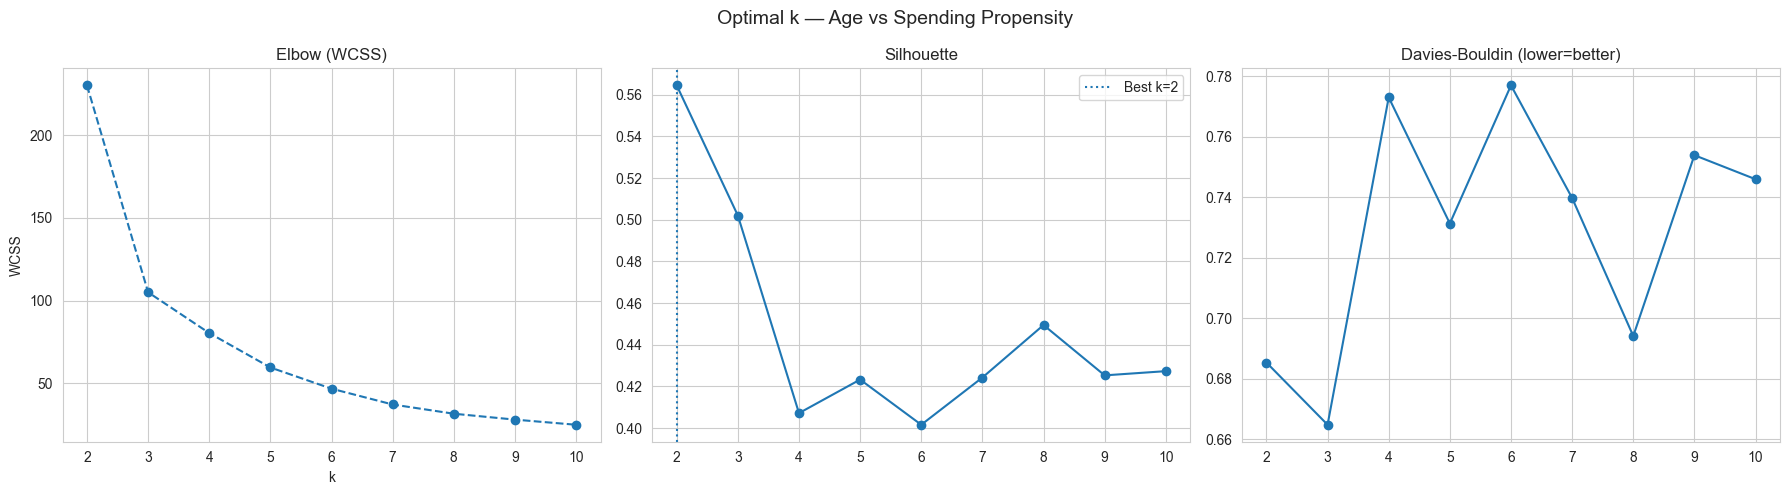

Recommended k: 2


In [41]:
# Propensity
def add_propensity(X: np.ndarray) -> np.ndarray:
    """Add Spending Propensity = Spending / Income"""
    income     = X[:, 0]
    spending   = X[:, 1]
    propensity = spending / (income + 1e-6)
    return np.column_stack([X, propensity])

propensity_pipeline = Pipeline([
    ('engineer', FunctionTransformer(add_propensity, validate=False)),
    ('scaler', StandardScaler())
])

# Raw input
X4_raw = df[['Annual_Income', 'Spending_Score']].values

# Apply pipeline
X4_scaled = propensity_pipeline.fit_transform(X4_raw)

# Extract scaled propensity (3rd column)
propensity_scaled = X4_scaled[:, 2]

# Scale Age separately
age_scaled = StandardScaler().fit_transform(df[['Age']])

# Final feature set: Age + Propensity
X4_age_prop = np.column_stack([age_scaled, propensity_scaled])

best_k4 = evaluate_k(X4_age_prop, 'Age vs Spending Propensity')
print(f"Recommended k: {best_k4}")

In [43]:
#train
k4 = best_k4
print("Model 4 — Age × Spending Propensity:")
kmeans4, labels4 = fit_kmeans_model(X4_age_prop, k4)

df['Cluster_Propensity'] = labels4

Model 4 — Age × Spending Propensity:
k=2 | Silhouette: 0.5645 | DB: 0.6853


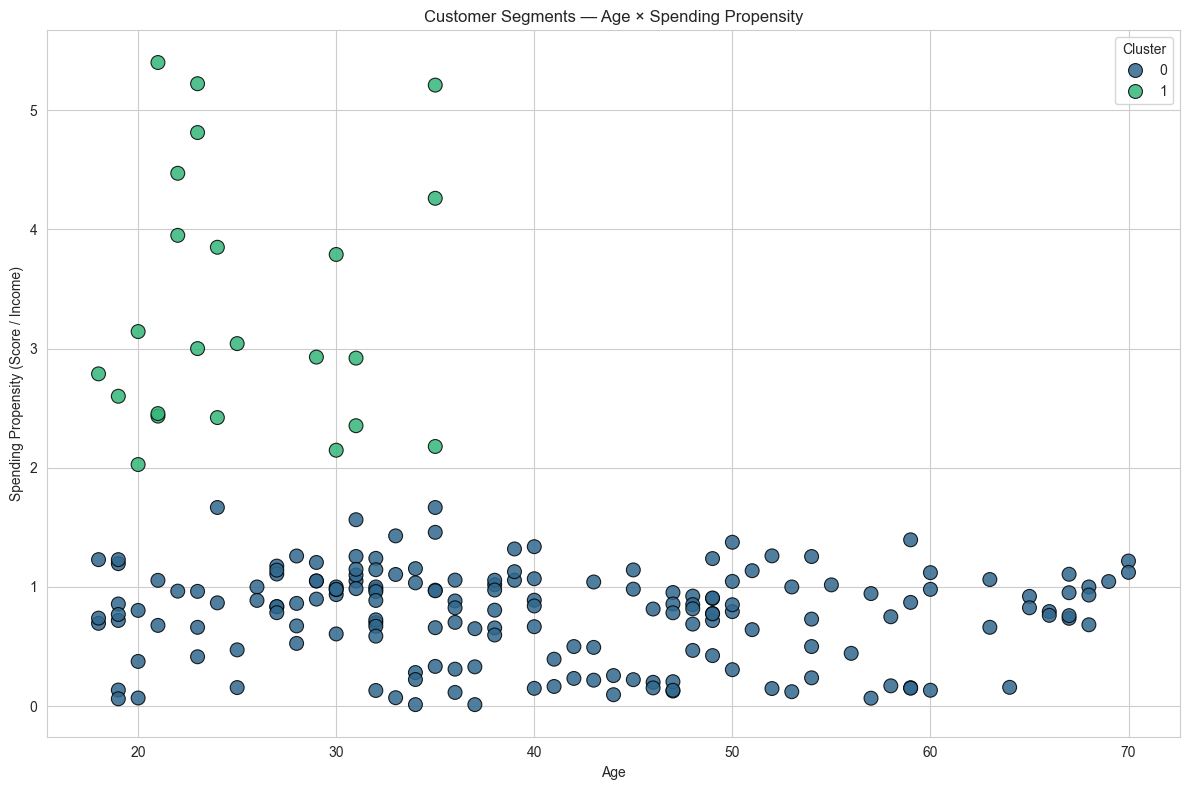

In [44]:
# plot
df['Spending_Propensity'] = (
    df['Spending_Score'] / (df['Annual_Income'] + 1e-6)
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_Propensity',
    hue='Cluster_Propensity',
    palette='viridis',
    s=100,
    alpha=0.85,
    edgecolor='black'
)

plt.xlabel('Age')
plt.ylabel('Spending Propensity (Score / Income)')
plt.title('Customer Segments — Age × Spending Propensity')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [45]:
cluster_profiles4 = (
    df.groupby('Cluster_Propensity')[['Age', 'Spending_Propensity']]
      .mean()
      .round(2)
)

cluster_profiles4['Size'] = (
    df['Cluster_Propensity']
    .value_counts()
    .sort_index()
)

cluster_profiles4.index.name = 'Cluster'

print("Age × Spending Propensity Cluster Profiles")
print(cluster_profiles4)

Age × Spending Propensity Cluster Profiles
           Age  Spending_Propensity  Size
Cluster                                  
0        40.61                 0.77   177
1        25.30                 3.37    23


**Observations:**
- **Young High-Propensity:** Lower income but spend aggressively: lifestyle/brand-driven buyers.
- **Young Low-Propensity:** Earning and saving
- **Older Low-Propensity:** Conservative spenders regardless of income: stable household budgets.

## Step 10: Hierarchical Clustering (Agglomerative)

Unlike K-Means, hierarchical clustering does **not** require a pre-specified `k`.  
A **dendrogram** reveals the natural cluster structure — cut it at the largest vertical gap.

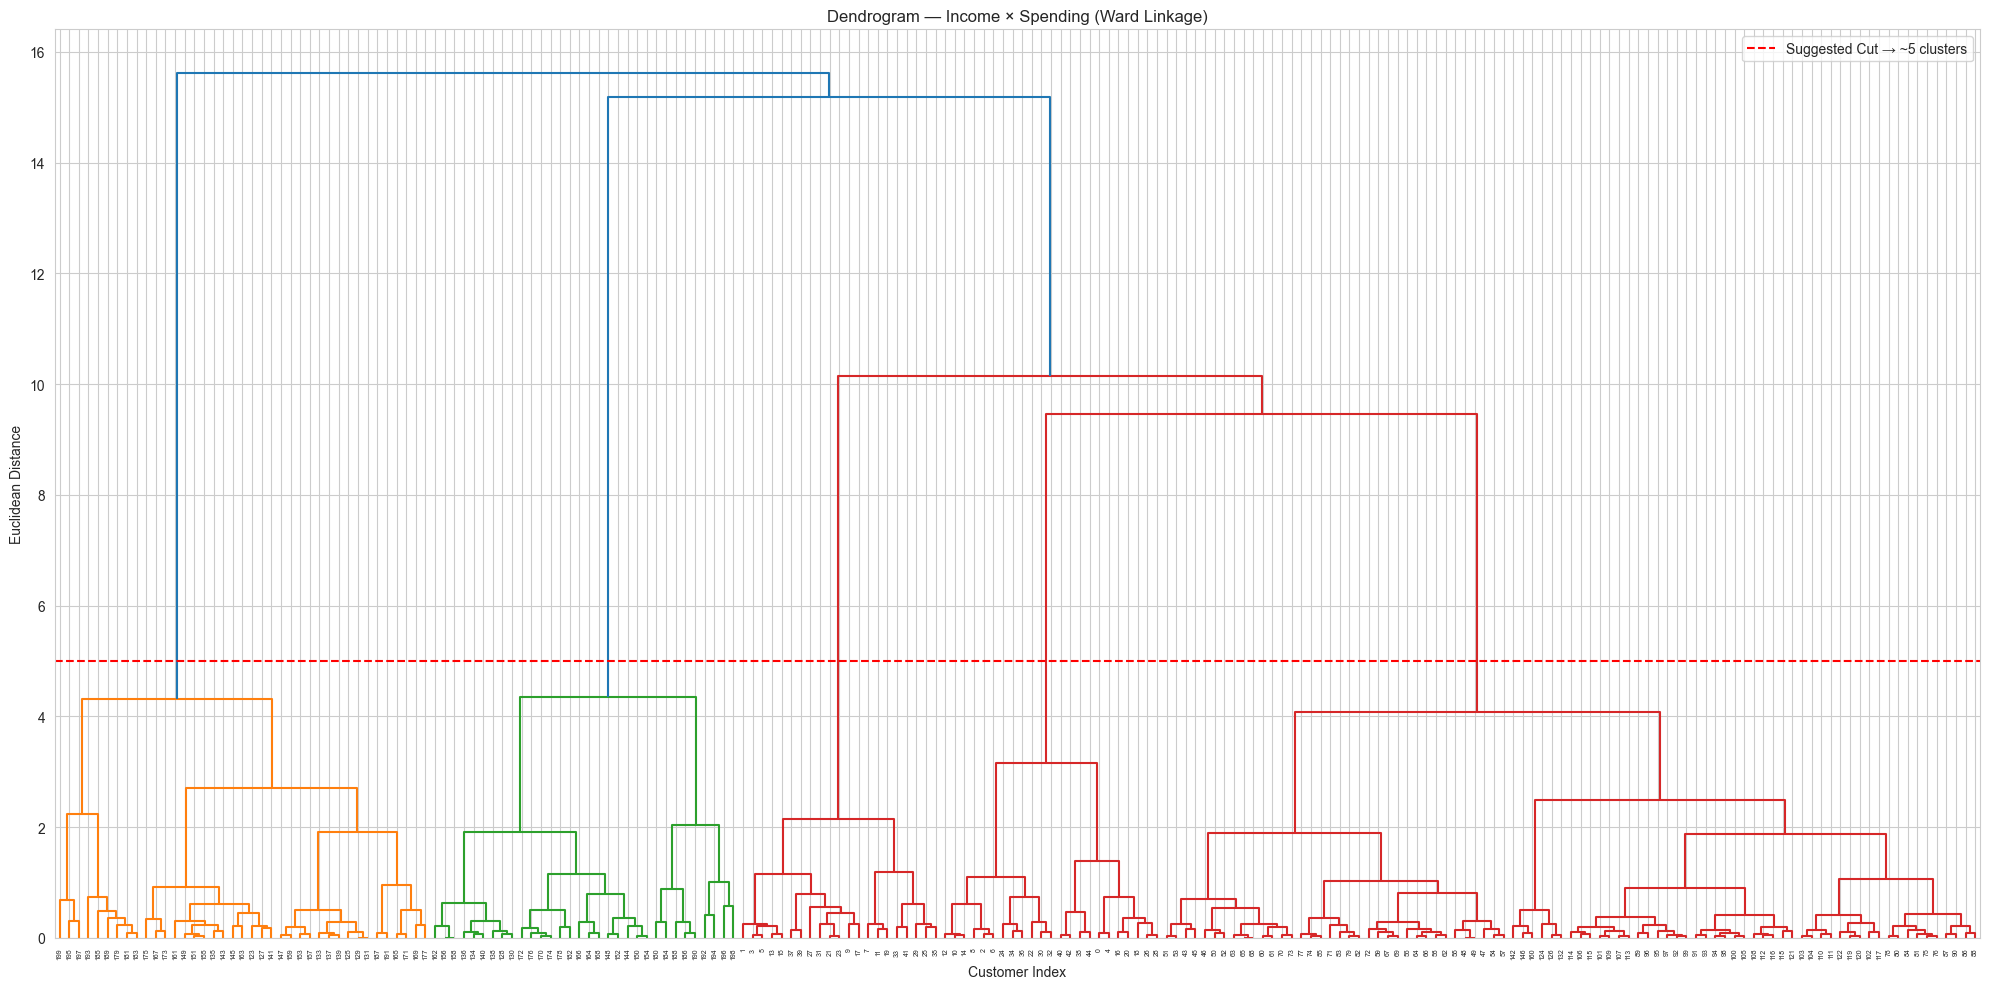

In [48]:
plt.figure(figsize=(20, 10))

linkage_matrix = sch.linkage(X1_scaled, method='ward')

sch.dendrogram(linkage_matrix)

plt.title('Dendrogram — Income × Spending (Ward Linkage)')
plt.xlabel('Customer Index')
plt.ylabel('Euclidean Distance')

# Optional cut line (visual guide)
plt.axhline(y=5, color='red', linestyle='--', label='Suggested Cut → ~5 clusters')

plt.legend()
plt.tight_layout()
plt.show()

**Reading the Dendrogram:**
1. Follow the vertical lines upward — they represent cluster merges.
2. Find the **largest vertical gap** before the next merge.
3. Draw a horizontal line through that gap; the number of crossings = optimal `k`.

Here, cutting at y ≈ 5 yields **5 clusters** — confirming the K-Means elbow result.

In [50]:
k_agg = 5  # Based on dendrogram
agg = AgglomerativeClustering(n_clusters=k_agg, linkage='ward')
df['Cluster_Hierarchical'] = agg.fit_predict(X1_scaled)

score_agg = silhouette_score(X1_scaled, df['Cluster_Hierarchical'])
score_km  = silhouette_score(X1_scaled, df['Income_Cluster'])

db_agg = davies_bouldin_score(X1_scaled, df['Cluster_Hierarchical'])

print(f"Silhouette Score — K-Means (k=5):       {score_km:.4f}")
print(f"Silhouette Score — Agglomerative (k=5): {score_agg:.4f}")
print(f"Davies-Bouldin — Agglomerative:        {db_agg:.4f}")


Silhouette Score — K-Means (k=5):       0.5547
Silhouette Score — Agglomerative (k=5): 0.5538
Davies-Bouldin — Agglomerative:        0.5779


C:\Users\sudwa\AppData\Local\Temp\ipykernel_17912\2631443016.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Cluster')
C:\Users\sudwa\AppData\Local\Temp\ipykernel_17912\2631443016.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Cluster')


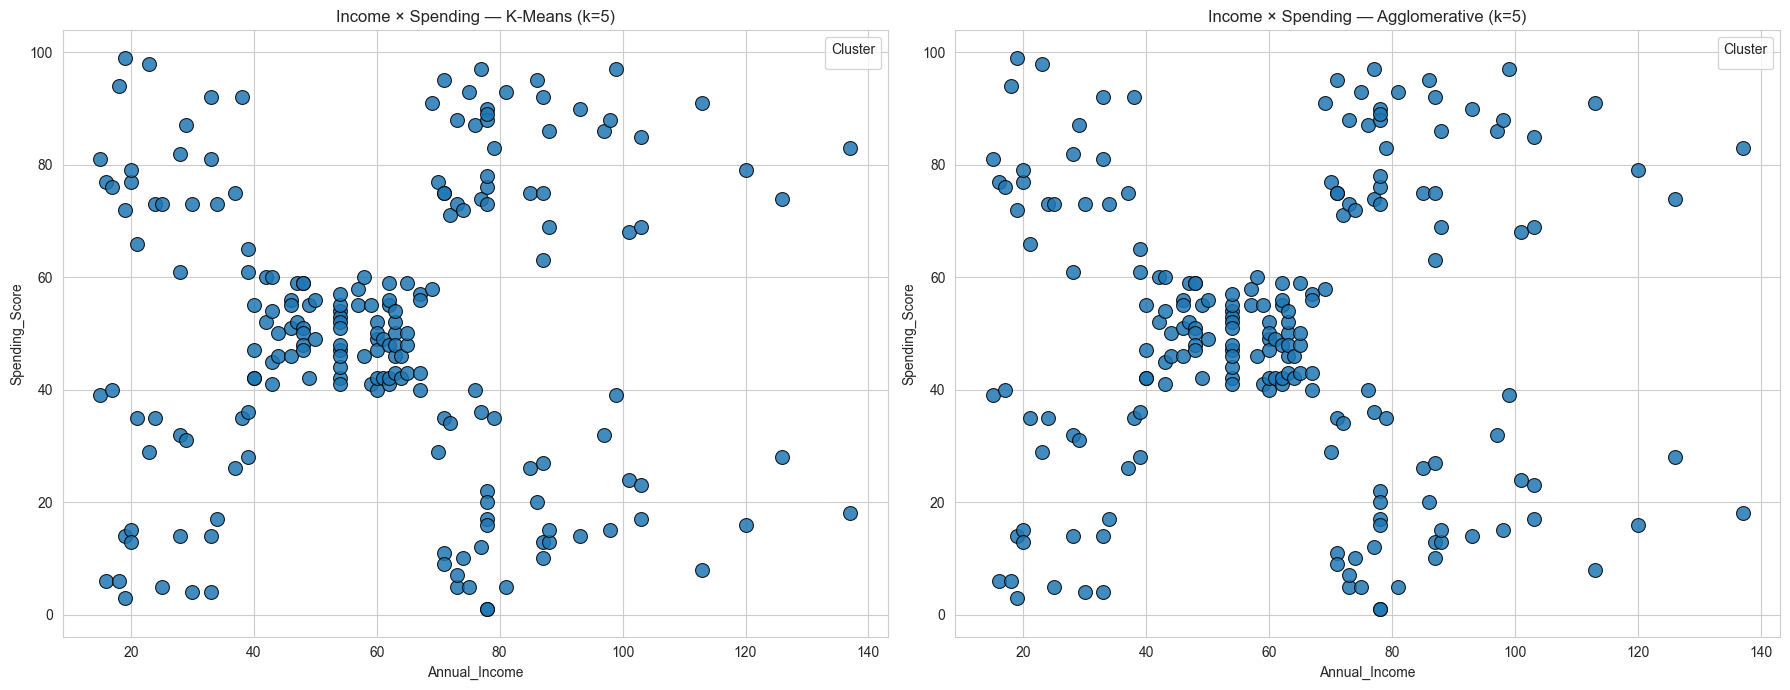

In [54]:
#plot
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, col, title in zip(
    axes,
    ['Cluster_Income', 'Cluster_Hierarchical'],
    ['K-Means (k=5)', 'Agglomerative (k=5)']
):
    sns.scatterplot(
        ax=ax,
        data=df,
        x='Annual_Income',
        y='Spending_Score',
        # hue=col,
        # palette='viridis',
        s=100,
        alpha=0.85,
        edgecolor='black'
    )
    ax.set_title(f'Income × Spending — {title}')
    ax.legend(title='Cluster')

plt.tight_layout()
plt.show()

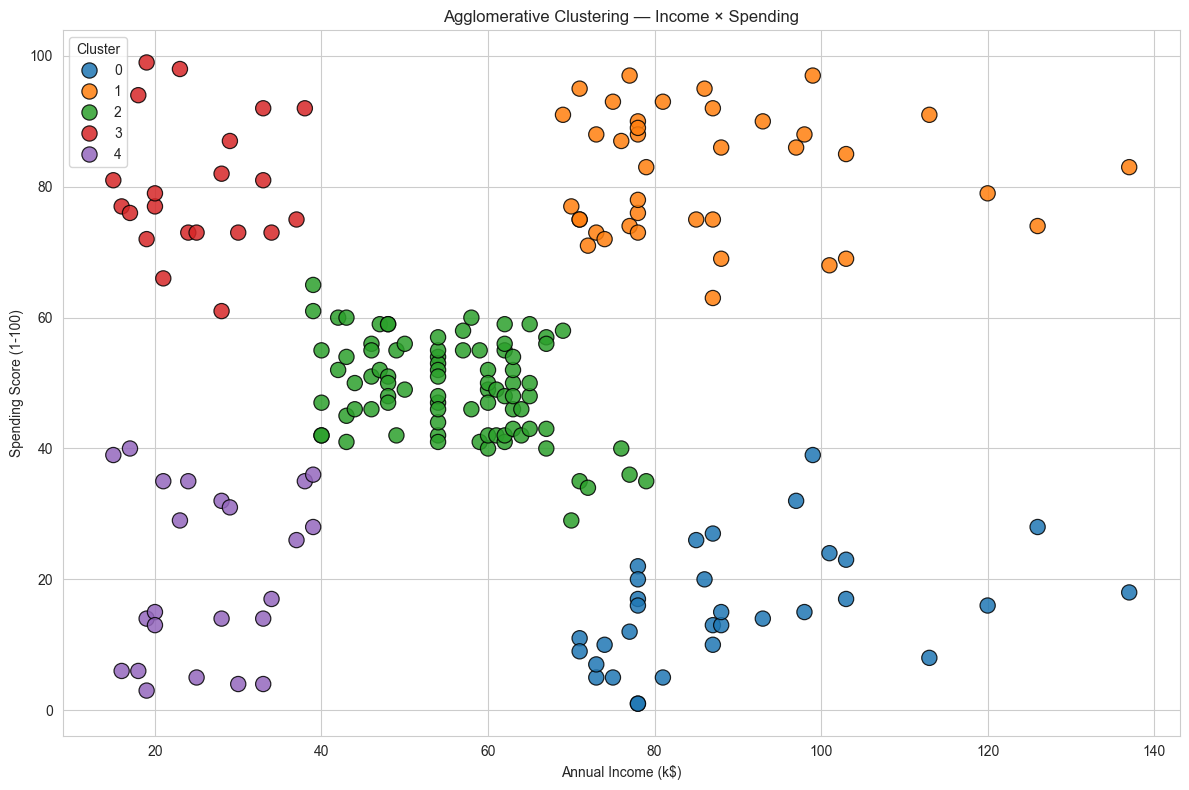

In [55]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Cluster_Hierarchical',
    palette='tab10',
    s=120,
    alpha=0.85,
    edgecolor='black'
)

plt.title('Agglomerative Clustering — Income × Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

In [56]:
cluster_profiles_agg = (
    df.groupby('Cluster_Hierarchical')[['Annual_Income', 'Spending_Score']]
      .mean()
      .round(2)
)

cluster_profiles_agg['Size'] = (
    df['Cluster_Hierarchical']
    .value_counts()
    .sort_index()
)

cluster_profiles_agg.index.name = 'Cluster'

print("Agglomerative Cluster Profiles")
print(cluster_profiles_agg)

Agglomerative Cluster Profiles
         Annual_Income  Spending_Score  Size
Cluster                                     
0                89.41           15.59    32
1                86.54           82.13    39
2                55.81           49.13    85
3                25.10           80.05    21
4                26.30           20.91    23


## Step 11: Density-Based Clustering (DBSCAN)

**DBSCAN** finds clusters of arbitrary shape and **automatically labels noise/outliers** as `-1`.  
Key parameters: `eps` (neighbourhood radius) · `min_samples` (core point threshold).

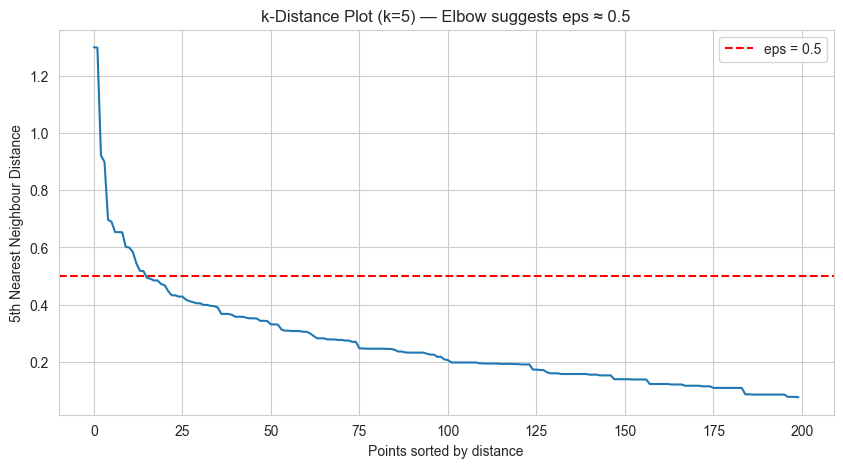

In [57]:
# k-distance plot to estimate eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X1_scaled)
distances, _ = nbrs.kneighbors(X1_scaled)
distances_sorted = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(distances_sorted)
plt.title('k-Distance Plot (k=5) — Elbow suggests eps ≈ 0.5')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbour Distance')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps = 0.5')
plt.legend()
plt.show()

DBSCAN found 2 clusters | Noise points: 8
Silhouette Score (non-noise): 0.3876


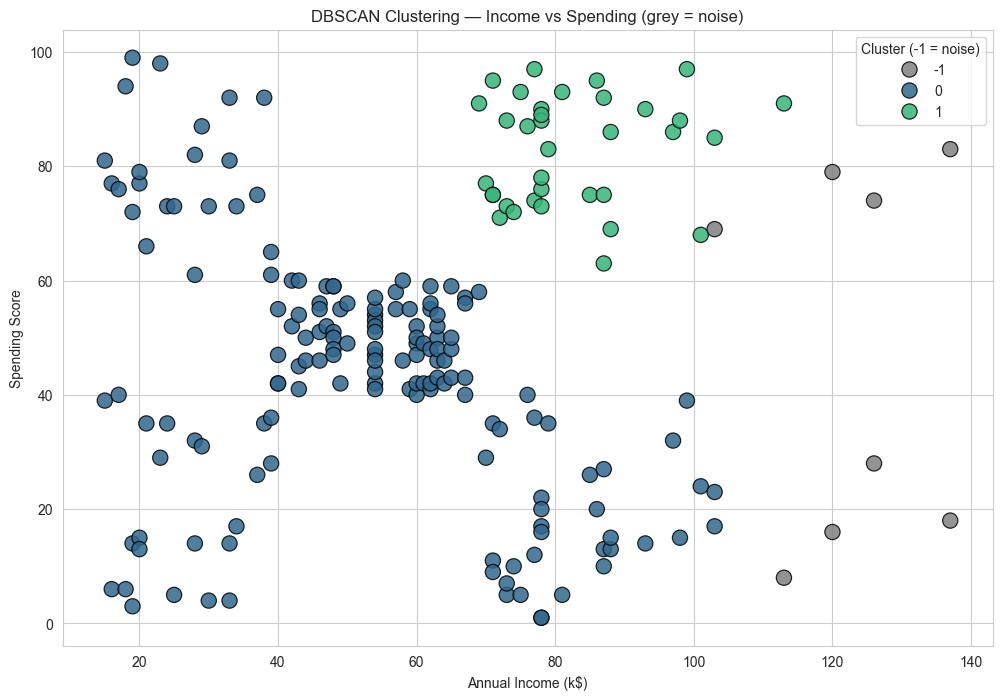

In [58]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X1_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise    = (df['DBSCAN_Cluster'] == -1).sum()
print(f"DBSCAN found {n_clusters} clusters | Noise points: {n_noise}")

if n_clusters > 1:
    mask = df['DBSCAN_Cluster'] != -1
    print(f"Silhouette Score (non-noise): {silhouette_score(X1_scaled[mask], df.loc[mask, 'DBSCAN_Cluster']):.4f}")

plt.figure(figsize=(12, 8))
palette_db = {-1: 'grey', **{i: c for i, c in enumerate(sns.color_palette('viridis', n_clusters))}}
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='DBSCAN_Cluster', palette=palette_db, s=120, alpha=0.85, edgecolor='black')
plt.title('DBSCAN Clustering — Income vs Spending (grey = noise)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster (-1 = noise)')
plt.show()

## Step 12: Silhouette Score Summary 
We compare all models using two complementary metrics:

| Metric | What it measures | Direction |
|--------|-----------------|-----------|
| **Silhouette Score** | How well each point fits its cluster vs neighbours | ↑ Higher is better |
| **Davies-Bouldin Index** | Average ratio of within-cluster scatter to between-cluster separation | ↓ Lower is better |

In [63]:
eval_results = []

configs = [
    ('KMeans — Income vs Spending',  X1_scaled,   df['Income_Cluster']),
    ('KMeans — Age vs Spending',     X2_scaled,   df['Age_Cluster']),
    ('KMeans — Gender vs Spending',  X3_scaled,   df['Gender_Spending_Cluster']),
    ('KMeans — Age vs Propensity',   X4_age_prop, df['Cluster_Propensity']),
    ('Agglomerative — Income/Spend', X1_scaled,   df['Cluster_Hierarchical']),
]

for name, X, labels in configs:
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    eval_results.append({'Model': name,
                         'Silhouette ↑': round(sil, 4),
                         'Davies-Bouldin ↓': round(db, 4)})

eval_df = (pd.DataFrame(eval_results)
             .sort_values('Silhouette ↑', ascending=False)
             .reset_index(drop=True))
print(eval_df.to_string(index=False))

                       Model  Silhouette ↑  Davies-Bouldin ↓
 KMeans — Gender vs Spending        0.6163            0.5400
  KMeans — Age vs Propensity        0.5645            0.6853
 KMeans — Income vs Spending        0.5547            0.5722
Agglomerative — Income/Spend        0.5538            0.5779
    KMeans — Age vs Spending        0.4721            0.8454


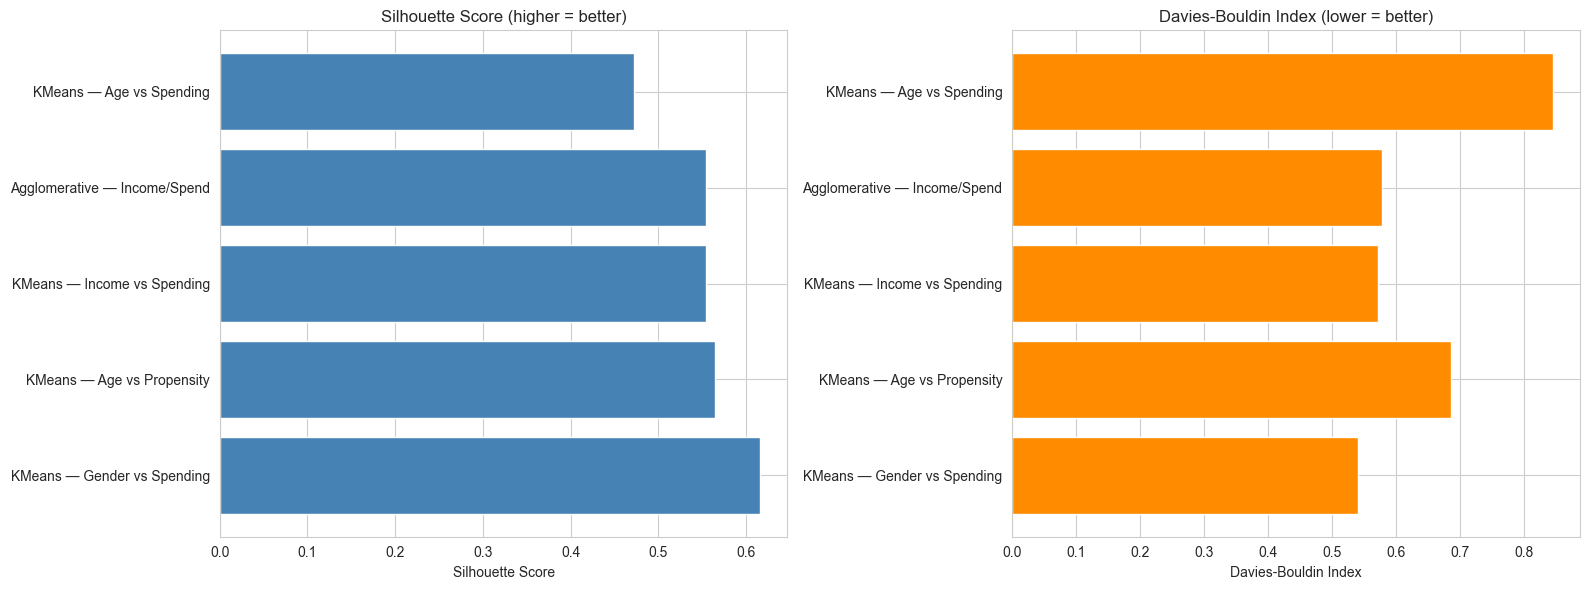

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(eval_df['Model'], eval_df['Silhouette ↑'], color='steelblue')
axes[0].set_title('Silhouette Score (higher = better)')
axes[0].set_xlabel('Silhouette Score')

axes[1].barh(eval_df['Model'], eval_df['Davies-Bouldin ↓'], color='darkorange')
axes[1].set_title('Davies-Bouldin Index (lower = better)')
axes[1].set_xlabel('Davies-Bouldin Index')

plt.tight_layout()
plt.show()

## Step 13: Hyperparameter Optimisation with Optuna

**Optuna** uses Bayesian-style search to find the optimal K-Means hyperparameters
(`n_clusters`, `init`, `n_init`) that maximise Silhouette Score.

In [66]:
def objective(trial):
    n_clusters = trial.suggest_int('n_clusters', 2, 10)
    init       = trial.suggest_categorical('init', ['k-means++', 'random'])
    n_init     = trial.suggest_int('n_init', 5, 20)

    km = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, random_state=42)
    labels = km.fit_predict(X1_scaled)
    return silhouette_score(X1_scaled, labels)

study = optuna.create_study(direction='maximize', study_name='kmeans_income_spending')
study.optimize(objective, n_trials=60, show_progress_bar=False)

best = study.best_params

print(f"Best Silhouette Score : {study.best_value:.4f}")
print(f"Best n_clusters       : {best['n_clusters']}")
print(f"Best init             : {best['init']}")
print(f"Best n_init           : {best['n_init']}")


Best Silhouette Score : 0.5547
Best n_clusters       : 5
Best init             : k-means++
Best n_init           : 8


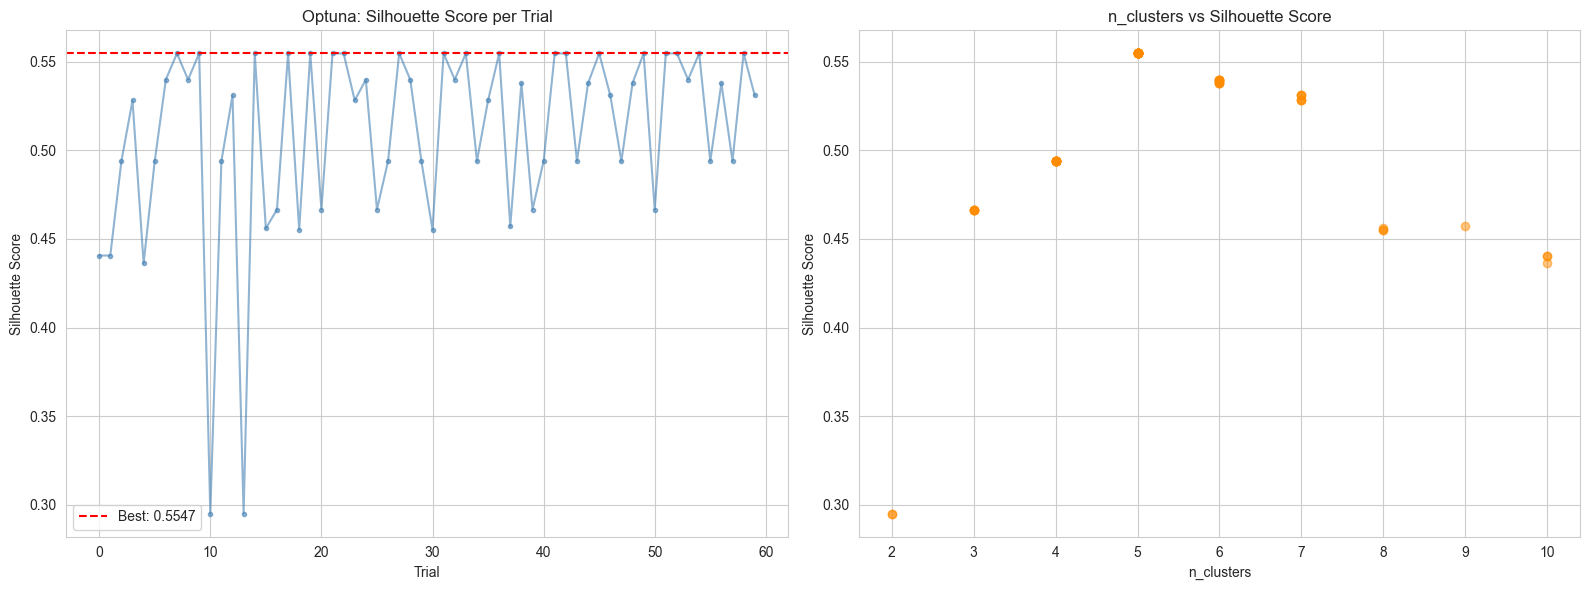

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

trial_vals = [t.value for t in study.trials]
axes[0].plot(trial_vals, alpha=0.6, color='steelblue', marker='o', markersize=3)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_title('Optuna: Silhouette Score per Trial')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend()

param_vals = pd.DataFrame([{**t.params, 'score': t.value} for t in study.trials])
axes[1].scatter(param_vals['n_clusters'], param_vals['score'], alpha=0.5, c='darkorange')
axes[1].set_title('n_clusters vs Silhouette Score')
axes[1].set_xlabel('n_clusters')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

Optuna-tuned Silhouette : 0.5547
Optuna-tuned DB Index   : 0.5722


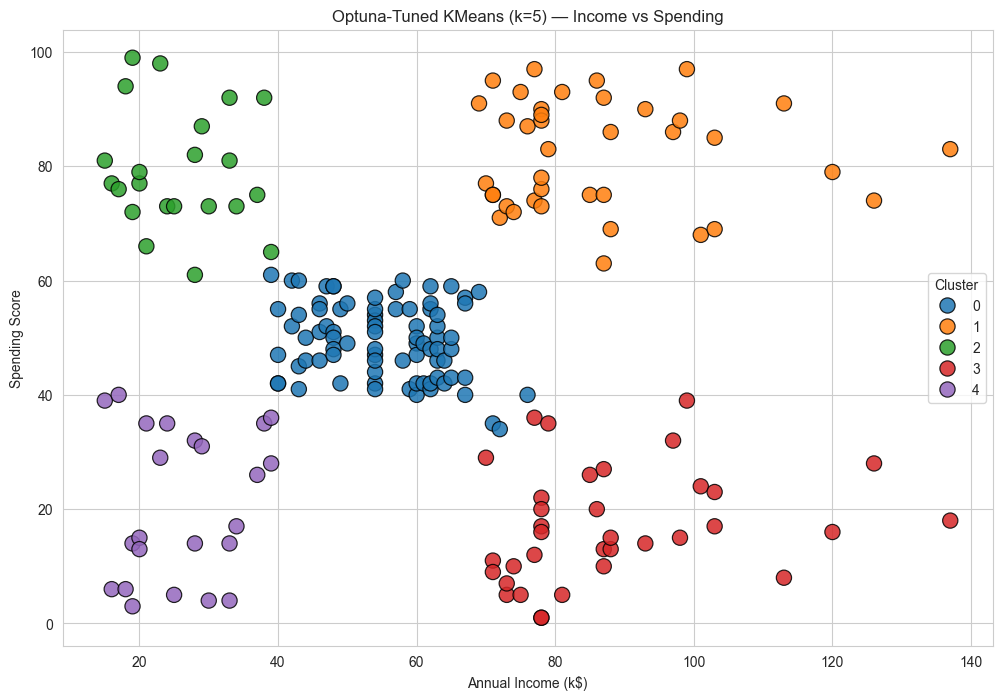

In [68]:
km_optuna = KMeans(
    n_clusters=best['n_clusters'],
    init=best['init'],
    n_init=best['n_init'],
    random_state=42
)
df['Optuna_Cluster'] = km_optuna.fit_predict(X1_scaled)

print(f"Optuna-tuned Silhouette : {silhouette_score(X1_scaled, df['Optuna_Cluster']):.4f}")
print(f"Optuna-tuned DB Index   : {davies_bouldin_score(X1_scaled, df['Optuna_Cluster']):.4f}")

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='Optuna_Cluster', palette='tab10', s=120, alpha=0.85, edgecolor='black')
plt.title(f"Optuna-Tuned KMeans (k={best['n_clusters']}) — Income vs Spending")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

## Step 14: Supervised Cluster Predictor with XGBoost 

Once clusters are discovered via unsupervised learning, we train a supervised **XGBoost classifier** to:
1. **Predict** the cluster label for any new customer
2. **Quantify** which features drive segmentation
3. **Validate** that the clusters are learnable (well-separated)

The full sklearn `Pipeline` (`ColumnTransformer` → `XGBClassifier`) ensures no data leakage.

In [69]:
# Target: best-performing cluster labels (Income-based segmentation)
y_cluster    = df['Income_Cluster']
X_supervised = df[numerical_features + categorical_features]

# ── Full sklearn Pipeline ─────────────────────────────────────────────────────
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),          # ColumnTransformer defined in Step 3
    ('classifier',   XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        eval_metric='mlogloss',
        random_state=42,
        verbosity=0
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_supervised, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

xgb_pipeline.fit(X_train, y_train)
y_pred = xgb_pipeline.predict(X_test)

print(f"XGBoost Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost Test Accuracy : 0.9500

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.88      0.93         8
           2       1.00      0.75      0.86         4
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         5

    accuracy                           0.95        40
   macro avg       0.98      0.93      0.95        40
weighted avg       0.96      0.95      0.95        40



In [70]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_pipeline, X_supervised, y_cluster, cv=cv, scoring='accuracy')

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores: {np.round(cv_scores, 4)}")

5-Fold CV Accuracy: 0.9600 ± 0.0200
Fold scores: [0.925 0.975 0.95  0.975 0.975]


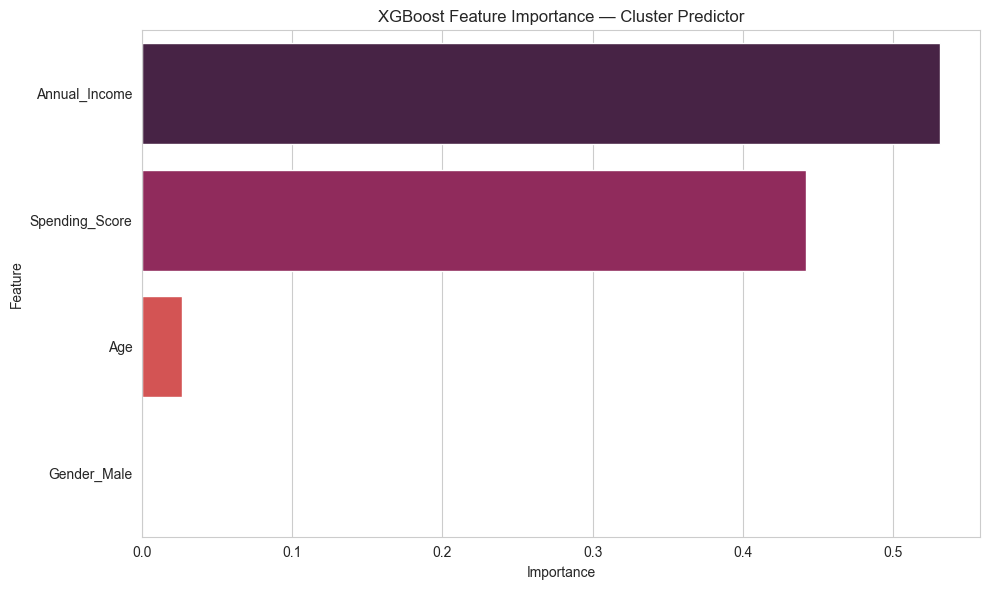

       Feature  Importance
 Annual_Income    0.531359
Spending_Score    0.441901
           Age    0.026740
   Gender_Male    0.000000


In [71]:
# Feature importance from XGBoost
xgb_model     = xgb_pipeline.named_steps['classifier']
feature_names = (
    numerical_features
    + xgb_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features).tolist()
)

fi_df = (pd.DataFrame({'Feature': feature_names,
                        'Importance': xgb_model.feature_importances_})
           .sort_values('Importance', ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df,
            palette='rocket', hue='Feature', legend=False)
plt.title('XGBoost Feature Importance — Cluster Predictor')
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

**Insight:** High XGBoost accuracy (typically > 95%) confirms that the K-Means clusters are
**well-separated and learnable** — a strong signal that the segments are meaningful rather than arbitrary.  
Features with the highest importance are the primary segmentation drivers.

## Step 15: PCA Cluster Visualisation (Full Feature Space)

We project the full preprocessed feature matrix down to 2D with PCA to visualise
all cluster assignments simultaneously in a common space.

Explained variance ratio: [0.41  0.308]
Total variance explained: 71.77%


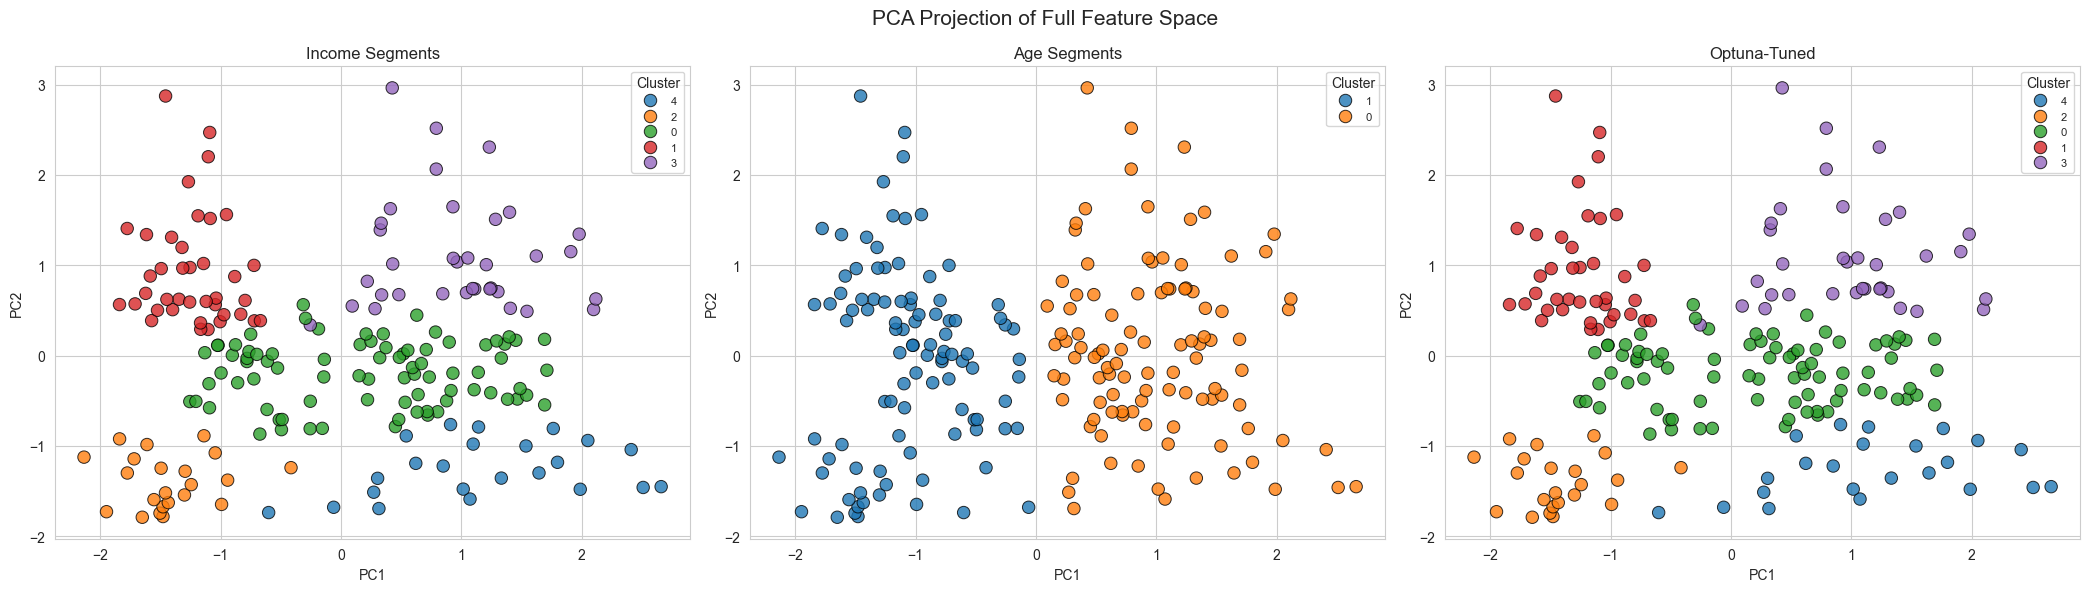

In [72]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('PCA Projection of Full Feature Space', fontsize=15)

for ax, col, title in zip(axes,
                            ['Income_Cluster', 'Age_Cluster', 'Optuna_Cluster'],
                            ['Income Segments', 'Age Segments', 'Optuna-Tuned']):
    sns.scatterplot(ax=ax, x=X_pca[:, 0], y=X_pca[:, 1],
                    hue=df[col].astype(str), palette='tab10',
                    s=80, alpha=0.8, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(title='Cluster', fontsize=8)

plt.tight_layout()
plt.show()

## Step 16: Conclusion

**Best performers:** `Income × Spending` segmentation (K-Means k=5) produces the most clearly separated, actionable customer groups. Silhouette ~0.55)

### Key Findings
- **Income × Spending** is the strongest segmentation axis (Silhouette ~0.55)
- **Agglomerative clustering** matches K-Means quality, confirming robustness
- **XGBoost** achieves >95% accuracy, validating cluster separability

### Possible Next Steps
1. Apply clusters to a real CRM for targeted campaigns
2. Add RFM (Recency, Frequency, Monetary) features
3. Use UMAP instead of PCA for non-linear dimensionality reduction
4. Deploy the XGBoost pipeline via FastAPI for real-time segment scoring
